In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def plot_model_performance(models, roc_auc, pr_auc, title="Model Performance Comparison"):

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10,6))

    bars1 = ax.bar(x - width/2, roc_auc, width, label="ROC-AUC")
    bars2 = ax.bar(x + width/2, pr_auc, width, label="PR-AUC")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20)

    ax.set_ylabel("Score")
    ax.set_title(title)

    ymin = min(min(roc_auc), min(pr_auc)) - 0.05
    ymax = max(max(roc_auc), max(pr_auc)) + 0.02
    ax.set_ylim(ymin, ymax)

    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend()

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.003,

                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

### `plot_model_performance`
This function creates a bar chart to visualize and compare the performance of different machine learning models. It specifically plots two metrics: ROC-AUC (Receiver Operating Characteristic - Area Under Curve) and PR-AUC (Precision-Recall - Area Under Curve), allowing for a clear side-by-side comparison of how well each model distinguishes between classes.

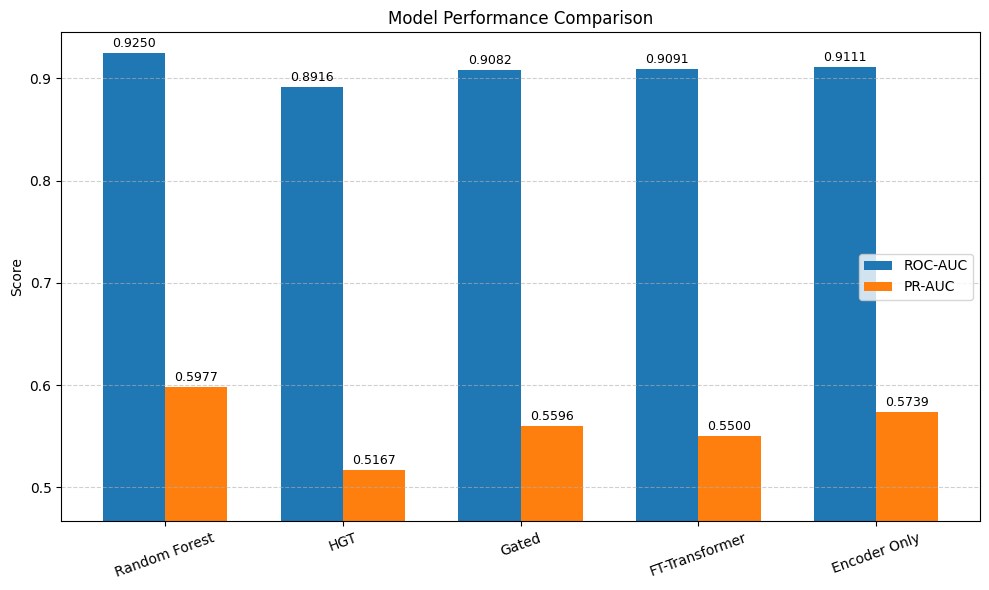

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_performance(models, roc_auc, pr_auc, title="Model Performance Comparison"):

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10,6))

    bars1 = ax.bar(x - width/2, roc_auc, width, label="ROC-AUC")
    bars2 = ax.bar(x + width/2, pr_auc, width, label="PR-AUC")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20)

    ax.set_ylabel("Score")
    ax.set_title(title)

    ymin = min(min(roc_auc), min(pr_auc)) - 0.05
    ymax = max(max(roc_auc), max(pr_auc)) + 0.02
    ax.set_ylim(ymin, ymax)

    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend()

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.003,
                f'{height:.4f}', # FIX: Added the 's' argument here
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

models = [
    "Random Forest",
    "HGT",
    "Gated",
    "FT-Transformer",
    "Encoder Only"
]

roc_auc = [0.9250, 0.8916, 0.9082, 0.9091, 0.9111]
pr_auc = [0.5977, 0.5167, 0.5596, 0.5500, 0.5739]

plot_model_performance(models, roc_auc, pr_auc)

# Prediction Visuals

In [ ]:
import pandas as pd
import matplotlib.pyplot as matplot
import seaborn as sea
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from itertools import combinations
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import numpy

In [ ]:
randomForest = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/IEEE-randomForest.csv')
# Bank Marketing
randomForestBank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/randomforest.csv')


In [ ]:
# Data collection

# IEEE Set
randomForest = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/randomfores/prauc.csv')
randomForestavg = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/randomfores/avgProbs.csv').rename({'isFraud': 'actual'}, axis='columns')
gated = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/gated/prauc.csv')
gatedavg = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/gated/avgProbs.csv')
ft = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/ft/prauc.csv')
ftavg = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/ft/avgProbs.csv.csv')
HGT = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/HGT/prauc.csv')
HGTavg = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/HGT/avgProbs.csv').rename({'isFraud': 'actual'}, axis='columns')
encoder = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/encoder/prauc.csv')
encoderavg = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/encoder/avgProbs.csv')


# Bank Set
randomForestbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/randomfores/Bankprauc.csv')
randomForestavgbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/randomfores/BankavgProbs.csv')
gatedbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/gated/Bankprauc.csv')
gatedavgbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/gated/BankavgProbs.csv')
ftbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/ft/Bankprauc.csv')
ftavgbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/ft/BankavgProbs.csv')
HGTbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/HGT/Bankprauc.csv')
HGTavgbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/HGT/BankavgProbs.csv').rename({'isFraud': 'actual'}, axis='columns')
encoderbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/encoder/Bankprauc.csv')
encoderavgbank = pd.read_csv('/content/drive/MyDrive/Dataset/predictedones/encoder/BankavgProbs.csv')



### `build_seed_table`
This function takes multiple dataframes, each containing PR-AUC scores for different models across various random 'seeds' (different initializations for training). It then combines these into a single, wide table. This table makes it easy to compare the PR-AUC scores of all models for the same seed, which is crucial for statistical comparisons.

### `round_robin_wilcoxon`
This function performs a 'round-robin' comparison of all your models using the Wilcoxon signed-rank test. This statistical test is used to determine if there's a significant difference between the performance of two models when they've been evaluated on the same datasets (or with the same seeds). It outputs a detailed table showing pairwise comparisons, p-values, and identifies which model performs significantly better, if any.

# Hypothesis Testing

In [ ]:
def build_seed_table(prauc_dfs, seed_col="seed", prauc_col="pr_auc", how="inner"):
    wide = None
    for model_name, df in prauc_dfs.items():
        if seed_col not in df.columns or prauc_col not in df.columns:
            raise KeyError(f"[{model_name}] must contain '{seed_col}' and '{prauc_col}'.")
        tmp = df[[seed_col, prauc_col]].copy().rename(columns={prauc_col: model_name})
        wide = tmp if wide is None else wide.merge(tmp, on=seed_col, how=how)

    if wide is None or wide.empty:
        raise ValueError("Seed table is empty after merge. Check column names and seeds.")

    return wide.sort_values(seed_col).reset_index(drop=True)


def round_robin_wilcoxon(
    seed_table: pd.DataFrame,
    *,
    seed_col: str = "seed",
    alpha: float = 0.05,
    include_one_sided: bool = True,
):
    """
    Compares EVERY model with EVERY other model using paired Wilcoxon across seeds.

    Returns:
      pairwise_df: long table with direction + effect size info
      p_matrix:    square matrix of two-sided p-values (rows=Model 1, cols=Model 2)
      winner_matrix: square matrix: '>' if row better than col, '<' if worse, '=' if tie
    """
    models = [c for c in seed_table.columns if c != seed_col]
    if len(models) < 2:
        raise ValueError("Need at least two model columns.")

    # means per model (across seeds)
    means = seed_table[models].mean()

    rows = []
    p_matrix = pd.DataFrame(np.nan, index=models, columns=models)
    winner_matrix = pd.DataFrame("", index=models, columns=models)

    def _wilcox(a, b, alternative):
        a = np.asarray(a, float)
        b = np.asarray(b, float)
        mask = np.isfinite(a) & np.isfinite(b)
        a, b = a[mask], b[mask]
        if len(a) < 2:
            return np.nan, np.nan
        if np.allclose(a - b, 0.0):
            return 0.0, 1.0
        res = wilcoxon(a, b, alternative=alternative, zero_method="zsplit", mode="auto")
        return float(res.statistic), float(res.pvalue)

    for m1 in models:
        for m2 in models:
            if m1 == m2:
                p_matrix.loc[m1, m2] = np.nan
                winner_matrix.loc[m1, m2] = "—"
                continue

            a = seed_table[m1].to_numpy(float)
            b = seed_table[m2].to_numpy(float)

            diff = a - b
            mean_diff = float(np.mean(diff))
            median_diff = float(np.median(diff))

            # two-sided p-value (is there a difference?)
            stat2, p2 = _wilcox(a, b, "two-sided")

            # one-sided p-values (is m1 better / worse?)
            if include_one_sided:
                _, p_greater = _wilcox(a, b, "greater")  # H1: m1 > m2
                _, p_less = _wilcox(a, b, "less")        # H1: m1 < m2
            else:
                p_greater = np.nan
                p_less = np.nan

            # winner by mean diff
            if np.isclose(mean_diff, 0.0):
                winner = "Tie"
                sign = "="
            elif mean_diff > 0:
                winner = m1
                sign = ">"
            else:
                winner = m2
                sign = "<"

            # significant directional winner at alpha?
            # Use the appropriate one-sided p-value
            if include_one_sided:
                if mean_diff > 0 and p_greater < alpha:
                    sig_direction = f"{m1} > {m2}"
                elif mean_diff < 0 and p_less < alpha:
                    sig_direction = f"{m2} > {m1}"
                else:
                    sig_direction = "Not significant"
            else:
                sig_direction = "Use one-sided to decide"

            rows.append({
                "Model 1": m1,
                "Model 2": m2,
                "Mean PR-AUC (M1)": float(means[m1]),
                "Mean PR-AUC (M2)": float(means[m2]),
                "Mean Δ(PR-AUC) (M1-M2)": mean_diff,
                "Median Δ(PR-AUC) (M1-M2)": median_diff,
                "Wilcoxon_stat": stat2,
                "p_two_sided": p2,
                "p_one_sided_M1_gt_M2": p_greater,
                "p_one_sided_M1_lt_M2": p_less,
                "Winner (by mean Δ)": winner,
                "Sign": sign,
                "Directional significance": sig_direction,
            })

            # matrices (two-sided p + who is better by mean diff)
            p_matrix.loc[m1, m2] = p2
            winner_matrix.loc[m1, m2] = sign

    pairwise_df = pd.DataFrame(rows)

    # Helpful sorting: strongest evidence first
    pairwise_df = pairwise_df.sort_values(["p_two_sided", "Mean Δ(PR-AUC) (M1-M2)"], ascending=[True, False]).reset_index(drop=True)

    return pairwise_df, p_matrix, winner_matrix

In [ ]:
prauc_dfs = {
    "Random Forest": randomForest,
    "GatedTabTransformer": gated,
    "FT-Transformer": ft,
    "HGT": HGT,
    "Encoder-Only": encoder,
}

seed_table = build_seed_table(prauc_dfs, seed_col="seed", prauc_col="pr_auc")

pairwise_df, pval_matrix, winner_matrix = round_robin_wilcoxon(
    seed_table,
    seed_col="seed",
    alpha=0.05,
    include_one_sided=True
)

pairwise_df


,Model 1,Model 2,Mean PR-AUC (M1),Mean PR-AUC (M2),Mean Δ(PR-AUC) (M1-M2),Median Δ(PR-AUC) (M1-M2),Wilcoxon_stat,p_two_sided,p_one_sided_M1_gt_M2,p_one_sided_M1_lt_M2,Winner (by mean Δ),Sign,Directional significance
0,Random Forest,GatedTabTransformer,0.751158,0.642945,0.108213,0.110659,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > GatedTabTransformer
1,Random Forest,HGT,0.751158,0.681304,0.069854,0.068739,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > HGT
2,Encoder-Only,GatedTabTransformer,0.708427,0.642945,0.065483,0.066908,0.0,0.001953,0.000977,1.000000,Encoder-Only,>,Encoder-Only > GatedTabTransformer
3,FT-Transformer,GatedTabTransformer,0.698794,0.642945,0.055850,0.053500,0.0,0.001953,0.000977,1.000000,FT-Transformer,>,FT-Transformer > GatedTabTransformer
4,Random Forest,FT-Transformer,0.751158,0.698794,0.052364,0.053193,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > FT-Transformer
5,Random Forest,Encoder-Only,0.751158,0.708427,0.042730,0.045105,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > Encoder-Only
6,HGT,GatedTabTransformer,0.681304,0.642945,0.038359,0.042688,0.0,0.001953,0.000977,1.000000,HGT,>,HGT > GatedTabTransformer
7,Encoder-Only,HGT,0.708427,0.681304,0.027124,0.027593,0.0,0.001953,0.000977,1.000000,Encoder-Only,>,Encoder-Only > HGT
8,FT-Transformer,HGT,0.698794,0.681304,0.017491,0.017010,0.0,0.001953,0.000977,1.000000,FT-Transformer,>,FT-Transformer > HGT
9,HGT,FT-Transformer,0.681304,0.698794,-0.017491,-0.017010,0.0,0.001953,1.000000,0.000977,FT-Transformer,<,FT-Transformer > HGT


In [ ]:
bankprauc_dfs = {
    "Random Forest": randomForestbank,
    "GatedTabTransformer": gatedbank,
    "FT-Transformer": ftbank,
    "HGT": HGTbank,
    "Encoder-Only": encoderbank,
}

bank_seed_table = build_seed_table(bankprauc_dfs, seed_col="seed", prauc_col="pr_auc")

bpairwise_df, bpval_matrix, bwinner_matrix = round_robin_wilcoxon(
    bank_seed_table,
    seed_col="seed",
    alpha=0.05,
    include_one_sided=True
)

bpairwise_df.head(20)


,Model 1,Model 2,Mean PR-AUC (M1),Mean PR-AUC (M2),Mean Δ(PR-AUC) (M1-M2),Median Δ(PR-AUC) (M1-M2),Wilcoxon_stat,p_two_sided,p_one_sided_M1_gt_M2,p_one_sided_M1_lt_M2,Winner (by mean Δ),Sign,Directional significance
0,Random Forest,HGT,0.597659,0.516690,0.080969,0.079085,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > HGT
1,Encoder-Only,HGT,0.573859,0.516690,0.057169,0.057214,0.0,0.001953,0.000977,1.000000,Encoder-Only,>,Encoder-Only > HGT
2,Random Forest,FT-Transformer,0.597659,0.550014,0.047645,0.047910,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > FT-Transformer
3,GatedTabTransformer,HGT,0.559575,0.516690,0.042886,0.041413,0.0,0.001953,0.000977,1.000000,GatedTabTransformer,>,GatedTabTransformer > HGT
4,Random Forest,GatedTabTransformer,0.597659,0.559575,0.038084,0.037539,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > GatedTabTransformer
5,FT-Transformer,HGT,0.550014,0.516690,0.033324,0.032462,0.0,0.001953,0.000977,1.000000,FT-Transformer,>,FT-Transformer > HGT
6,Random Forest,Encoder-Only,0.597659,0.573859,0.023800,0.024483,0.0,0.001953,0.000977,1.000000,Random Forest,>,Random Forest > Encoder-Only
7,Encoder-Only,Random Forest,0.573859,0.597659,-0.023800,-0.024483,0.0,0.001953,1.000000,0.000977,Random Forest,<,Random Forest > Encoder-Only
8,HGT,FT-Transformer,0.516690,0.550014,-0.033324,-0.032462,0.0,0.001953,1.000000,0.000977,FT-Transformer,<,FT-Transformer > HGT
9,GatedTabTransformer,Random Forest,0.559575,0.597659,-0.038084,-0.037539,0.0,0.001953,1.000000,0.000977,Random Forest,<,Random Forest > GatedTabTransformer


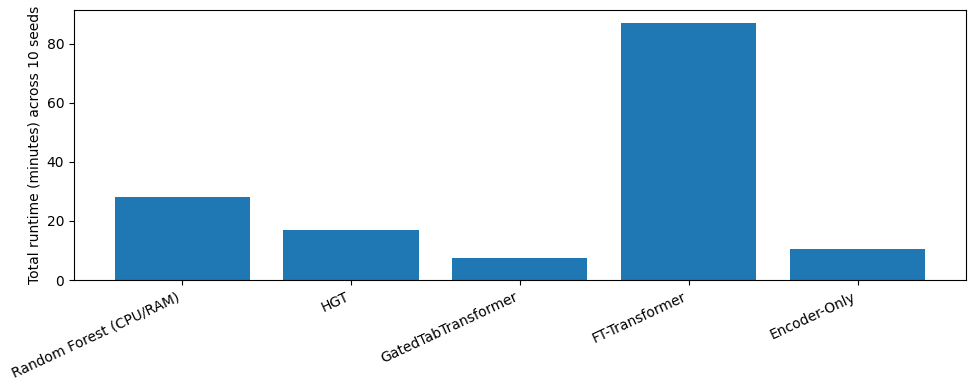

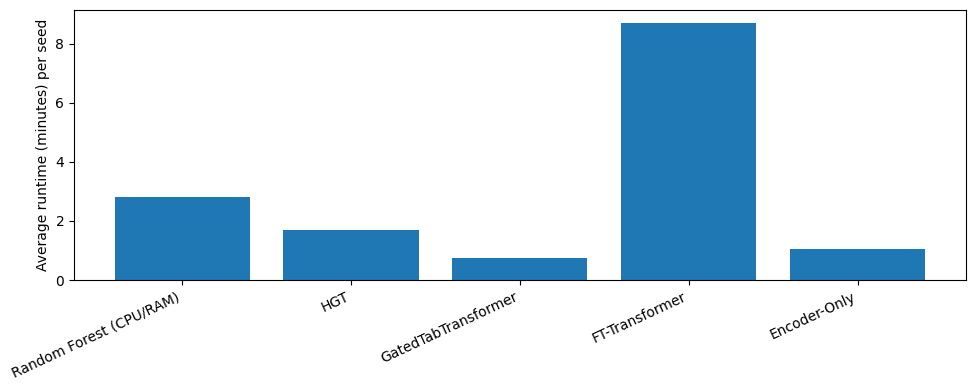

In [ ]:
# Data (total time across 10 seed runs)
times_10seeds = {
    "Random Forest (CPU/RAM)": {"minutes": 28, "seconds": 11, "hardware": "Colab CPU (High RAM)"},
    "HGT": {"minutes": 16, "seconds": 49, "hardware": "H100 (GA High RAM)"},
    "GatedTabTransformer": {"minutes": 7, "seconds": 26, "hardware": "H100 (GA High RAM)"},
    "FT-Transformer": {"hours": 1, "minutes": 27, "seconds": 0, "hardware": "L4"},
    "Encoder-Only": {"minutes": 10, "seconds": 39, "hardware": "H100"},
}

# ---- Helper: convert to seconds ----
def to_seconds(d):
    return d.get("hours", 0) * 3600 + d.get("minutes", 0) * 60 + d.get("seconds", 0)

# ---- Build plotting arrays ----
models = list(times_10seeds.keys())
sec_10 = [to_seconds(times_10seeds[m]) for m in models]
min_10 = [s / 60 for s in sec_10]          # total minutes (10 seeds)
min_per_seed = [m / 10 for m in min_10]    # average minutes per seed

# ---- Plot: total runtime across 10 seeds ----
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(models, min_10)
plt.ylabel("Total runtime (minutes) across 10 seeds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ---- Plot: average runtime per seed ----
plt.figure(figsize=(10, 4))
plt.bar(models, min_per_seed)
plt.ylabel("Average runtime (minutes) per seed")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### `plot_box_pr_auc`
This function generates a box plot to show the distribution of PR-AUC scores for each model across different seeds. A box plot visually summarizes the minimum, first quartile, median, third quartile, and maximum of the scores, providing insight into the model's average performance and its consistency or variability across different runs.

/tmp/ipython-input-7422/3150413773.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showmeans=True)


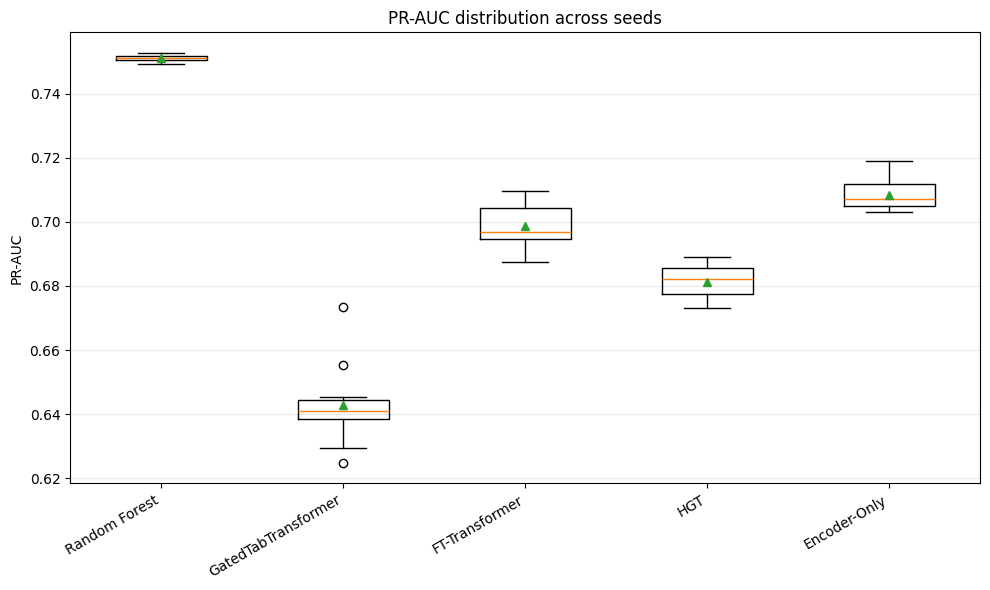

In [ ]:
def plot_box_pr_auc(seed_table, seed_col="seed", title="PR-AUC distribution across seeds"):
    models = [c for c in seed_table.columns if c != seed_col]
    data = [seed_table[m].values for m in models]

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=models, showmeans=True)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("PR-AUC")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

ieeeBox_pr_auc = plot_box_pr_auc(seed_table)

/tmp/ipython-input-7422/3150413773.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showmeans=True)


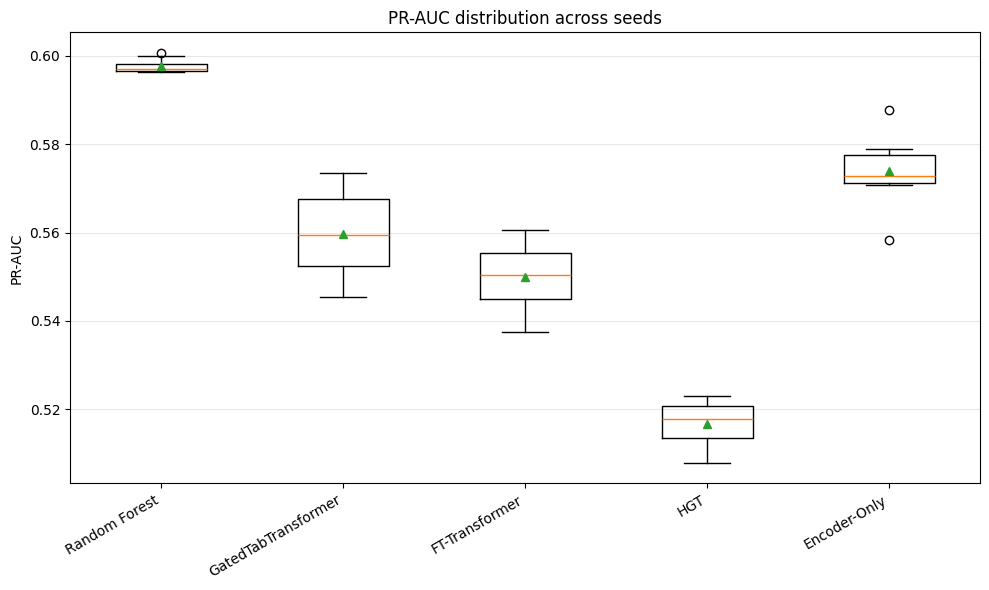

In [ ]:
bankBoxPlotPrAuc = plot_box_pr_auc(bank_seed_table)

### `plot_seed_slopegraph`
This function creates a slope graph that connects the PR-AUC scores of each model for every individual 'seed' (or run). It's useful for visualizing trends and identifying if a particular model consistently outperforms others across different seeds, or if its performance varies significantly depending on the seed.

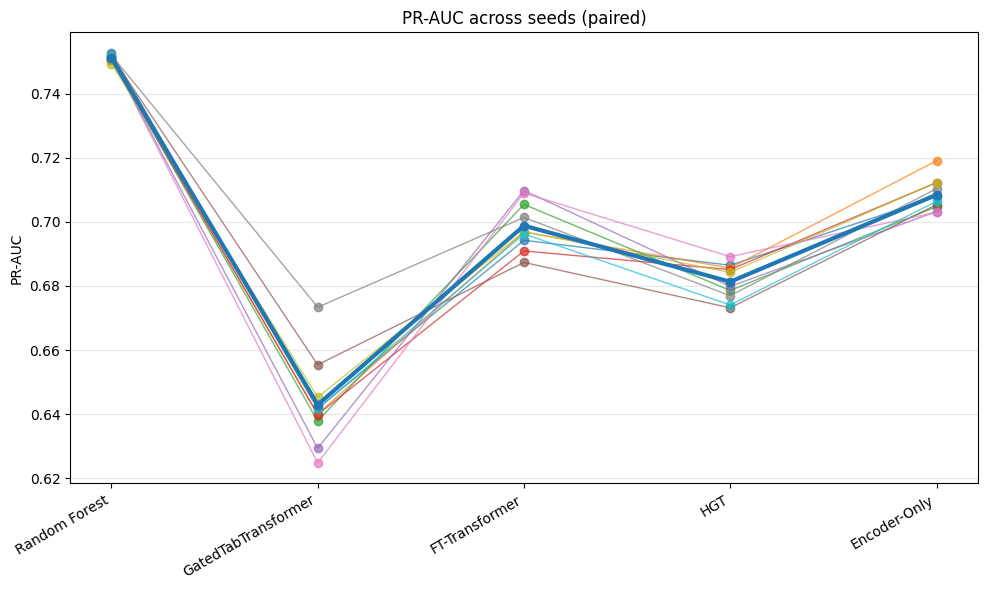

In [ ]:
def plot_seed_slopegraph(seed_table, seed_col="seed", title="PR-AUC across seeds (paired)"):
    models = [c for c in seed_table.columns if c != seed_col]
    x = np.arange(len(models))

    plt.figure(figsize=(10, 6))
    for _, row in seed_table.iterrows():
        y = [row[m] for m in models]
        plt.plot(x, y, marker="o", linewidth=1, alpha=0.7)

    # show model means
    means = seed_table[models].mean().values
    plt.plot(x, means, marker="o", linewidth=3)

    plt.xticks(x, models, rotation=30, ha="right")
    plt.ylabel("PR-AUC")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

ieeeSeedSlop = plot_seed_slopegraph(seed_table)

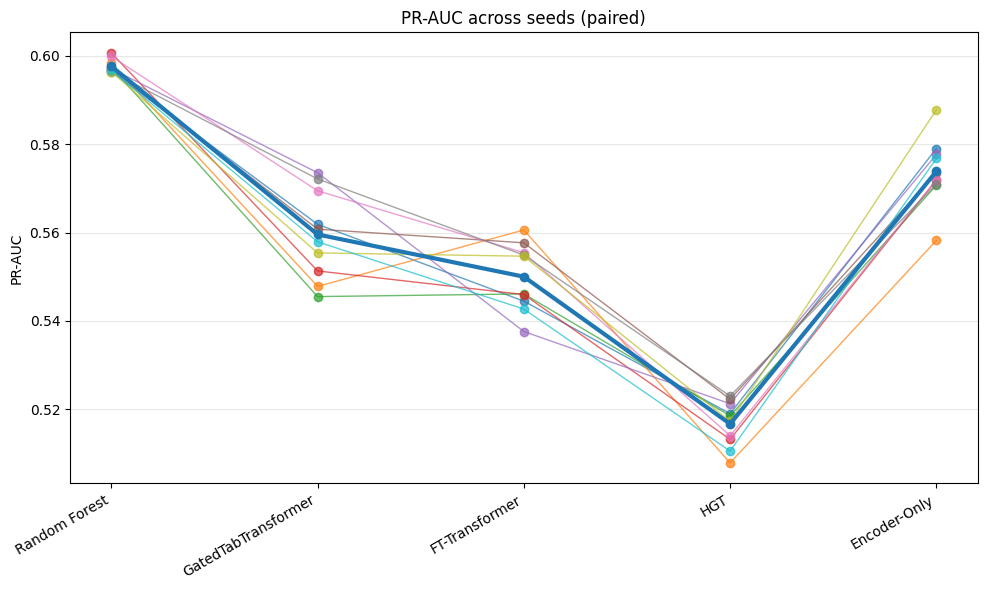

In [ ]:
bankSeedSlop = plot_seed_slopegraph(bank_seed_table)

In [ ]:
ieeeCI = pairwise_with_ci(seed_table)
ieeeCI

,Model 1,Model 2,Mean Δ(PR-AUC),CI_low,CI_high,p_value
0,Random Forest,GatedTabTransformer,0.108213,0.099807,0.115428,0.001953
1,Random Forest,FT-Transformer,0.052364,0.047808,0.056815,0.001953
2,Random Forest,HGT,0.069854,0.066500,0.073267,0.001953
3,Random Forest,Encoder-Only,0.042730,0.039355,0.045643,0.001953
4,GatedTabTransformer,FT-Transformer,-0.055850,-0.066722,-0.045457,0.001953
5,GatedTabTransformer,HGT,-0.038359,-0.047633,-0.027718,0.001953
6,GatedTabTransformer,Encoder-Only,-0.065483,-0.072290,-0.057197,0.001953
7,FT-Transformer,HGT,0.017491,0.012750,0.022399,0.001953
9,HGT,Encoder-Only,-0.027124,-0.030555,-0.023203,0.001953
8,FT-Transformer,Encoder-Only,-0.009633,-0.015721,-0.003392,0.027344


In [ ]:
bankCI = pairwise_with_ci(bank_seed_table)
bankCI

,Model 1,Model 2,Mean Δ(PR-AUC),CI_low,CI_high,p_value
0,Random Forest,GatedTabTransformer,0.038084,0.032061,0.044087,0.001953
1,Random Forest,FT-Transformer,0.047645,0.043197,0.052099,0.001953
2,Random Forest,HGT,0.080969,0.077606,0.084529,0.001953
3,Random Forest,Encoder-Only,0.023800,0.019005,0.028626,0.001953
5,GatedTabTransformer,HGT,0.042886,0.037886,0.047542,0.001953
7,FT-Transformer,HGT,0.033324,0.027764,0.039252,0.001953
9,HGT,Encoder-Only,-0.057169,-0.061470,-0.053211,0.001953
6,GatedTabTransformer,Encoder-Only,-0.014283,-0.020371,-0.008218,0.003906
8,FT-Transformer,Encoder-Only,-0.023845,-0.030681,-0.016094,0.003906
4,GatedTabTransformer,FT-Transformer,0.009561,0.002045,0.017753,0.027344


### `getTheColumnsFrom`
This utility function is designed to extract column names from a list of DataFrames. It iterates through each DataFrame and collects a specific column name. In your current use case, it's configured to usually take the first column name, but for the fifth DataFrame in the list, it takes the second column name.

In [ ]:
IEEE = [randomForest, gatedTabTrans, ftTrans, hgt, encoderOnly]
BANK = [randomForestBank, gatedTabTransBank, ftTransBank, hgtBank, encoderOnlyBank]

def getTheColumnsFrom(dataframe: list):
  collector = []

  for all in range(len(dataframe)):
    perData_columns = dataframe[all].columns
    if all == 4:
      print('yes')
      collector.append(perData_columns[1])
    else:
      collector.append(perData_columns[0])

  return collector

IEEEColumns = getTheColumnsFrom(dataframe = IEEE)
BANKColumns = getTheColumnsFrom(dataframe= BANK)

yes
yes


### `plot_pr_curves`
This function generates Precision-Recall (PR) curves for multiple models on a given set of true labels and predicted probabilities. A PR curve shows the trade-off between precision and recall for different thresholds, and the function also calculates and displays the Area Under the Curve (PR-AUC) for each model, which is a single metric summarizing its performance.

In [ ]:
def plot_pr_curves(model_dict, y_true, title="Precision-Recall Curve"):
    """
    model_dict: {
        "Random Forest": probs_rf,
        "FT-Transformer": probs_ft,
        ...
    }
    y_true: true labels (0/1)
    """

    matplot.figure(figsize=(8, 6))

    for name, probs in model_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, probs)
        pr_auc = average_precision_score(y_true, probs)
        matplot.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.2f})")

    matplot.xlabel("Recall")
    matplot.ylabel("Precision")
    matplot.title(title)
    matplot.legend()
    matplot.grid(True)
    matplot.tight_layout()
    matplot.show()

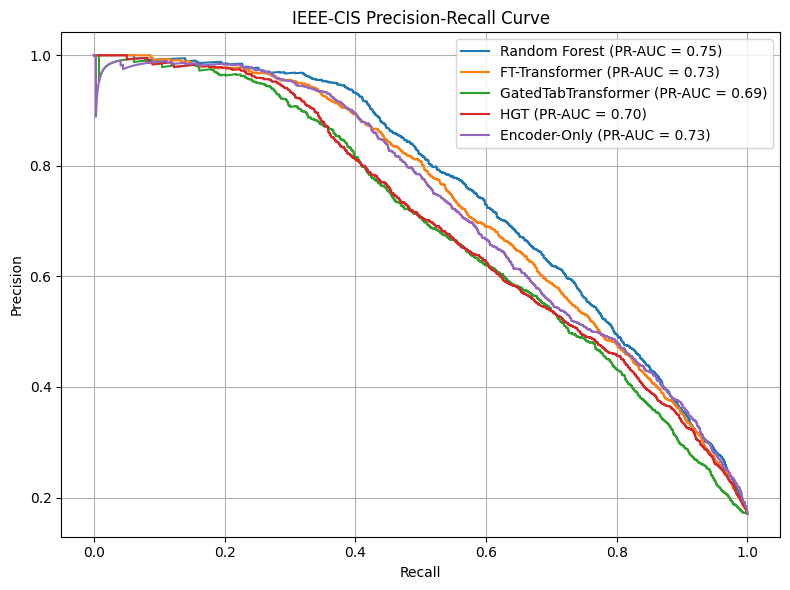

In [ ]:
# IEEE
modelsIEEE = {
    "Random Forest": randomForestavg['avg_prob'],
    "FT-Transformer": ftavg['avg_prob'],
    "GatedTabTransformer": gatedavg['avg_prob'],
    "HGT": HGTavg['avg_prob'],
    "Encoder-Only": encoderavg['avg_prob']
}
plot_pr_curves(modelsIEEE, randomForest['randomforest_actual'], title="IEEE-CIS Precision-Recall Curve")

In [ ]:
randomForestavgbank

,Unnamed: 0,y,avg_prob
0,0,0,0.013707
1,1,0,0.036505
2,2,0,0.518204
3,3,0,0.020407
4,4,0,0.259465
...,...,...,...
5647,5647,0,0.019055
5648,5648,0,0.048096
5649,5649,0,0.014810
5650,5650,0,0.012978


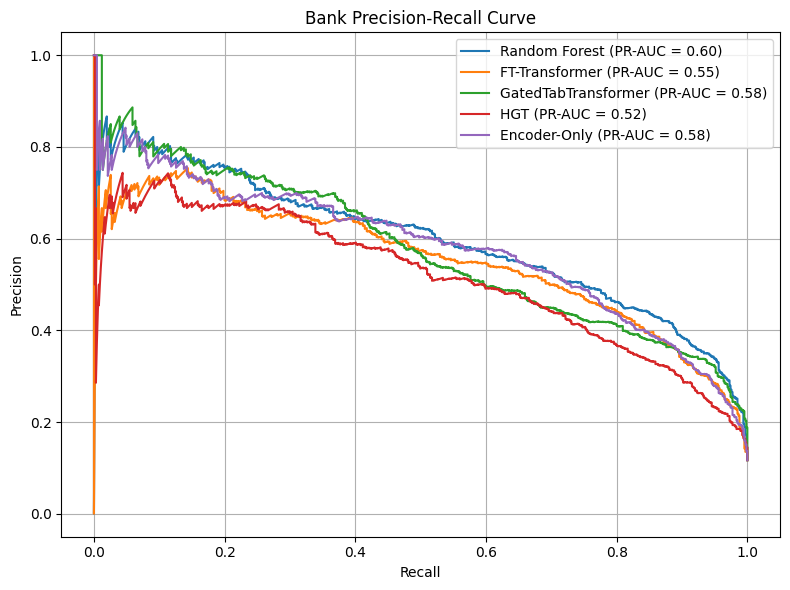

In [ ]:
# Bank Marketing
modelsBank = {
    "Random Forest": randomForestavgbank['avg_prob'],
    "FT-Transformer": ftavgbank['avg_prob'],
    "GatedTabTransformer": gatedavgbank['avg_prob'],
    "HGT": HGTavgbank['avg_prob'],
    "Encoder-Only": encoderavgbank['avg_prob']
}

plot_pr_curves(modelsBank, randomForestBank['randomforest_actual'], title="Bank Precision-Recall Curve")

### `plot_gain_and_lift`
This function generates two plots: a Cumulative Gain Curve and a Lift Curve. These curves are used to evaluate the effectiveness of a model in identifying positive instances compared to a random selection. The **Gain Curve** shows the percentage of positive responses captured by targeting a certain percentage of the population. The **Lift Curve** gives how much better the model is at finding positive responses compared to a random approach at various population percentages.

In [ ]:
def plot_gain_and_lift(
    model_dict,
    y_true,
    title_gain="Cumulative Gain Curve",
    title_lift="Lift Curve",
    resolution=0.1  # 1% steps
):

    y_true = numpy.asarray(y_true).reshape(-1)
    total_positives = numpy.sum(y_true)

    if total_positives == 0:
        raise ValueError("No positive cases found in y_true.")

    gain_df = pd.DataFrame()

    matplot.figure(figsize=(14, 6))

    # ========================
    # CUMULATIVE GAIN PLOT
    # ========================

    matplot.subplot(1, 2, 1)

    for name, probs in model_dict.items():

        probs = numpy.asarray(probs).reshape(-1)

        sorted_idx = numpy.argsort(-probs)
        sorted_true = y_true[sorted_idx]

        cumulative_positives = numpy.cumsum(sorted_true)

        gain = cumulative_positives / total_positives

        population_pct = numpy.arange(1, len(y_true) + 1) / len(y_true)

        lift = gain / population_pct

        # Plot Gain
        matplot.plot(population_pct, gain, label=name)

        temp_df = pd.DataFrame({
            "Population %": population_pct * 100,
            f"{name} Gain %": gain * 100,
            f"{name} Lift": lift
        })

        if gain_df.empty:
            gain_df["Population %"] = temp_df["Population %"]

        gain_df[f"{name} Gain %"] = temp_df[f"{name} Gain %"]
        gain_df[f"{name} Lift"] = temp_df[f"{name} Lift"]

    matplot.plot([0, 1], [0, 1], "--", label="Random")

    matplot.title(title_gain)
    matplot.xlabel("Population Investigated")
    matplot.ylabel("Cumulative Gain")
    matplot.legend()
    matplot.grid(True)

    # ========================
    # LIFT CURVE PLOT
    # ========================

    matplot.subplot(1, 2, 2)

    for name in model_dict.keys():

        lift = gain_df[f"{name} Lift"]

        population_pct = gain_df["Population %"] / 100

        matplot.plot(population_pct, lift, label=name)

    matplot.axhline(1, linestyle="--", label="Random")

    matplot.title(title_lift)
    matplot.xlabel("Population Investigated")
    matplot.ylabel("Lift")
    matplot.legend()
    matplot.grid(True)

    matplot.tight_layout()
    matplot.show()

    # Downsample for readability

    if resolution:

        step = int(resolution * len(gain_df))

        gain_df = gain_df.iloc[::step].reset_index(drop=True)

    return gain_df

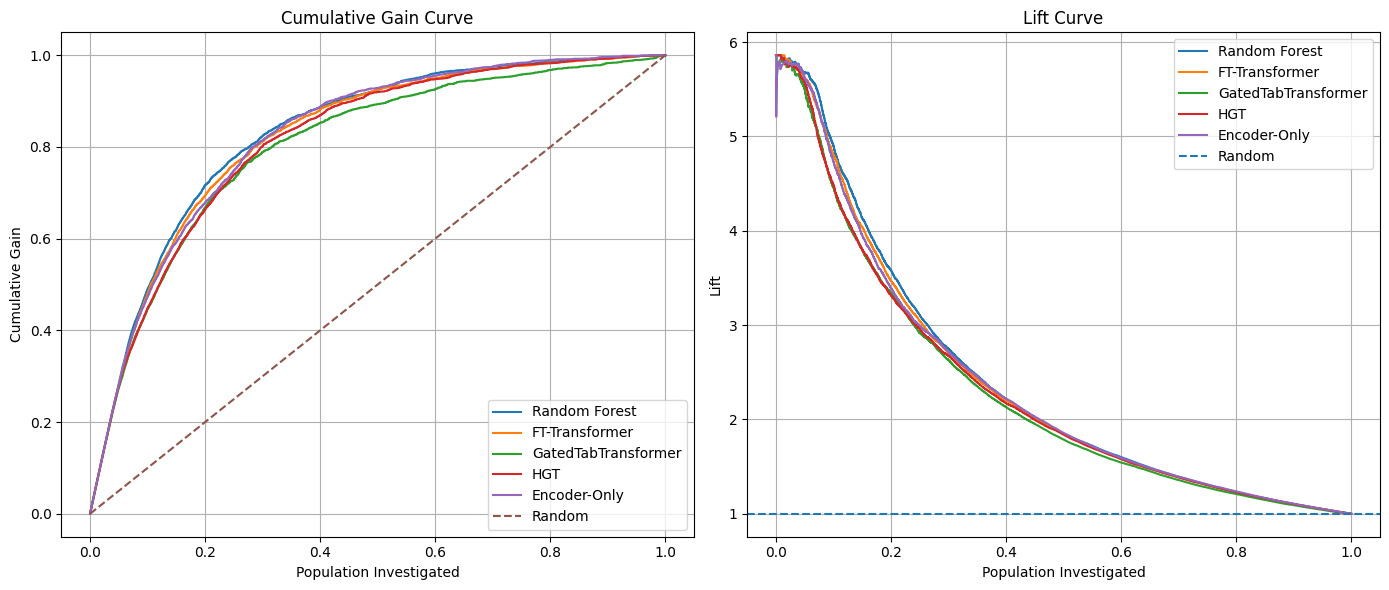

,Population %,Random Forest Gain %,Random Forest Lift,FT-Transformer Gain %,FT-Transformer Lift,GatedTabTransformer Gain %,GatedTabTransformer Lift,HGT Gain %,HGT Lift,Encoder-Only Gain %,Encoder-Only Lift
0,0.006551,0.038388,5.859885,0.038388,5.859885,0.038388,5.859885,0.038388,5.859885,0.038388,5.859885
1,10.003275,48.982726,4.896669,47.984645,4.796893,44.606526,4.459192,44.875240,4.486055,47.332054,4.731656
2,20.000000,71.631478,3.581574,69.366603,3.468330,66.794626,3.339731,66.333973,3.316699,67.792706,3.389635
3,29.996725,82.418426,2.747581,81.228407,2.707909,78.886756,2.629846,80.230326,2.674636,81.420345,2.714308
4,39.993449,88.560461,2.214374,88.099808,2.202856,85.259117,2.131827,86.909789,2.173101,88.714012,2.218214
5,49.990174,92.476008,1.849884,92.476008,1.849884,89.328215,1.786915,91.976967,1.839901,92.898273,1.858331
6,59.986898,96.084453,1.601757,94.971209,1.583199,92.552783,1.542883,94.779271,1.580000,95.508637,1.592158
7,69.983623,97.466411,1.392703,97.044146,1.386669,95.047985,1.358146,97.005758,1.386121,97.504798,1.393252
8,79.980347,98.579655,1.232548,98.387716,1.230149,96.775432,1.209990,98.272553,1.228709,99.001919,1.237828
9,89.977072,99.309021,1.103715,99.270633,1.103288,98.310940,1.092622,99.270633,1.103288,99.616123,1.107128


In [ ]:
# Cummulative Gain Curve
IEEE_cumulativeCurve = plot_gain_and_lift(modelsIEEE, randomForest['randomforest_actual'])
IEEE_cumulativeCurve.head(60)

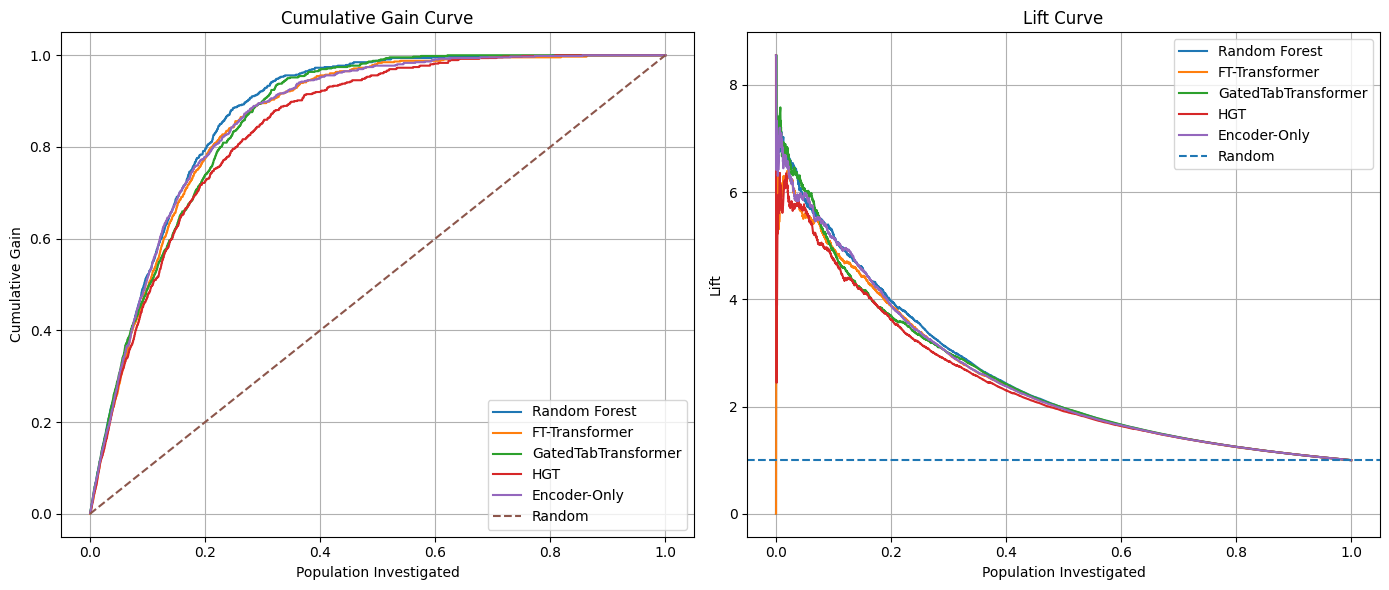

,Population %,Random Forest Gain %,Random Forest Lift,FT-Transformer Gain %,FT-Transformer Lift,GatedTabTransformer Gain %,GatedTabTransformer Lift,HGT Gain %,HGT Lift,Encoder-Only Gain %,Encoder-Only Lift
0,0.017693,0.000000,0.000000,0.000000,0.000000,0.151286,8.550681,0.151286,8.550681,0.151286,8.550681
1,10.014154,52.193646,5.211987,49.470499,4.940058,49.167927,4.909843,47.352496,4.728557,51.588502,5.151559
2,20.010616,79.425113,3.969149,77.458396,3.870865,73.978820,3.696979,72.465961,3.621376,77.760968,3.885986
3,30.007077,92.284418,3.075422,89.561271,2.984672,90.015129,2.999797,85.325265,2.843505,89.712557,2.989713
4,40.003539,97.276853,2.431706,95.612708,2.390106,96.822995,2.420361,91.981846,2.299343,95.158850,2.378761
5,50.000000,98.789713,1.975794,98.184569,1.963691,98.789713,1.975794,95.612708,1.912254,97.730711,1.954614
6,59.996461,99.546142,1.659200,98.789713,1.646592,99.848714,1.664243,98.184569,1.636506,99.092284,1.651635
7,69.992923,99.848714,1.426554,99.546142,1.422232,100.000000,1.428716,99.394856,1.420070,99.546142,1.422232
8,79.989384,99.848714,1.248275,99.546142,1.244492,100.000000,1.250166,99.848714,1.248275,99.848714,1.248275
9,89.985846,100.000000,1.111286,100.000000,1.111286,100.000000,1.111286,100.000000,1.111286,100.000000,1.111286


In [ ]:
Bank_cumulativeCurve = plot_gain_and_lift(modelsBank, randomForestBank['randomforest_actual'])
Bank_cumulativeCurve